In [4]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('ipl_2022_dataset.csv')
df.head()


Saving ipl_2022_dataset.csv to ipl_2022_dataset (1).csv


,Unnamed: 0,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team
0,0,Rashid Khan,Draft Pick,BOWLER,15.0,1950.0,SRH,Gujarat Titans
1,1,Hardik Pandya,Draft Pick,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans
2,2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans
3,3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans
4,4,Shubman Gill,Draft Pick,BATTER,8.0,1040.0,KKR,Gujarat Titans


In [5]:
df.shape


(633, 8)

In [6]:
df.info()b

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       633 non-null    int64  
 1   Player           633 non-null    object 
 2   Base Price       633 non-null    object 
 3   TYPE             633 non-null    object 
 4   COST IN ₹ (CR.)  237 non-null    float64
 5   Cost IN $ (000)  237 non-null    float64
 6   2021 Squad       199 non-null    object 
 7   Team             633 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 39.7+ KB


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       633 non-null    int64  
 1   Player           633 non-null    object 
 2   Base Price       633 non-null    object 
 3   TYPE             633 non-null    object 
 4   COST IN ₹ (CR.)  237 non-null    float64
 5   Cost IN $ (000)  237 non-null    float64
 6   2021 Squad       199 non-null    object 
 7   Team             633 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 39.7+ KB


In [8]:
df.describe()

,Unnamed: 0,COST IN ₹ (CR.),Cost IN $ (000)
count,633.000000,237.000000,237.000000
mean,316.000000,3.695781,480.451477
std,182.875641,4.238092,550.951945
min,0.000000,0.200000,26.000000
25%,158.000000,0.400000,52.000000
50%,316.000000,1.900000,247.000000
75%,474.000000,6.500000,845.000000
max,632.000000,17.000000,2210.000000


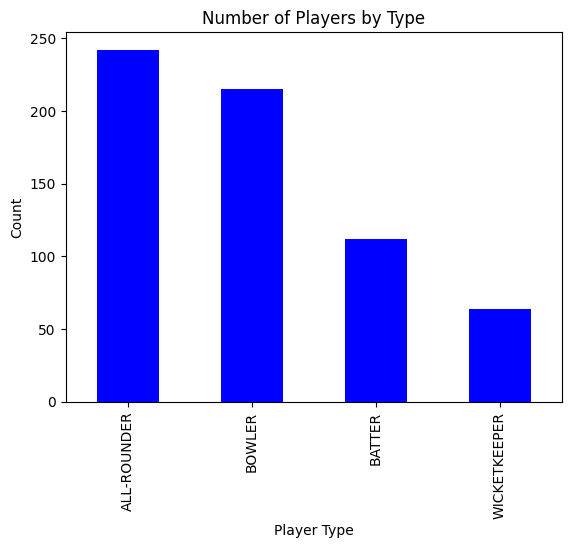

In [9]:
import matplotlib.pyplot as plt

df['TYPE'].value_counts().plot(kind='bar', color='blue')
plt.title('Number of Players by Type')
plt.xlabel('Player Type')
plt.ylabel('Count')
plt.show()

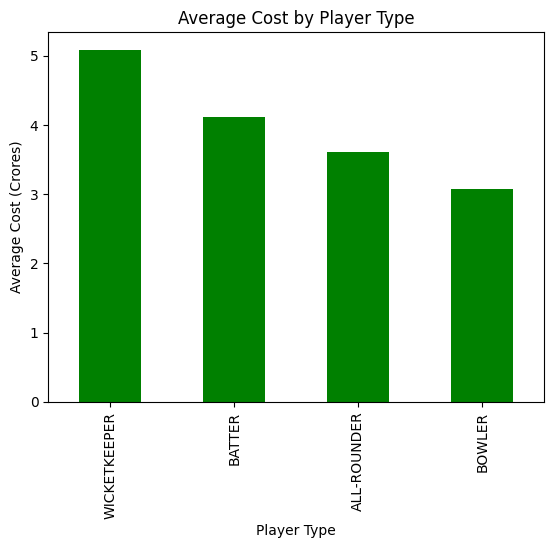

In [10]:
df.groupby('TYPE')['COST IN ₹ (CR.)'].mean().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Average Cost by Player Type')
plt.xlabel('Player Type')
plt.ylabel('Average Cost (Crores)')
plt.show()

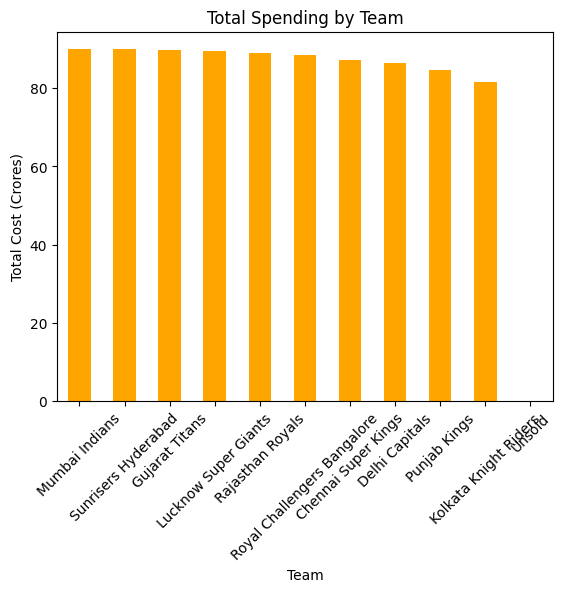

In [11]:
df.groupby('Team')['COST IN ₹ (CR.)'].sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Total Spending by Team')
plt.xlabel('Team')
plt.ylabel('Total Cost (Crores)')
plt.xticks(rotation=45)
plt.show()

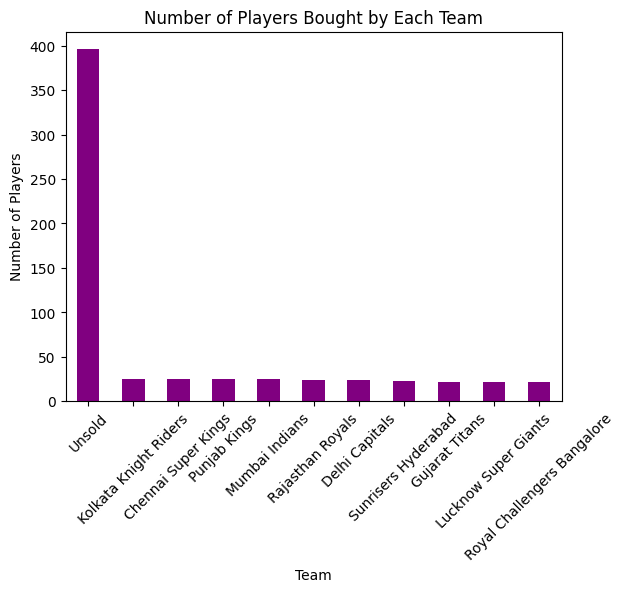

In [12]:
df.groupby('Team')['Player'].count().sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Number of Players Bought by Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

In [13]:
most_expensive = df.nlargest(10, 'COST IN ₹ (CR.)')
print(most_expensive[['Player', 'TYPE', 'COST IN ₹ (CR.)', 'Team']])

              Player          TYPE  COST IN ₹ (CR.)  \
121         KL Rahul  WICKETKEEPER            17.00   
22   Ravindra Jadeja   ALL-ROUNDER            16.00   
47      Rishabh Pant  WICKETKEEPER            16.00   
143     Rohit Sharma        BATTER            16.00   
144     Ishan Kishan  WICKETKEEPER            15.25   
0        Rashid Khan        BOWLER            15.00   
1      Hardik Pandya   ALL-ROUNDER            15.00   
168      Virat Kohli        BATTER            15.00   
23     Deepak Chahar        BOWLER            14.00   
190     Sanju Samson  WICKETKEEPER            14.00   

                            Team  
121         Lucknow Super Giants  
22           Chennai Super Kings  
47                Delhi Capitals  
143               Mumbai Indians  
144               Mumbai Indians  
0                 Gujarat Titans  
1                 Gujarat Titans  
168  Royal Challengers Bangalore  
23           Chennai Super Kings  
190             Rajasthan Royals  


In [14]:
team_stats = df.groupby('Team').agg(
    Total_Spent=('COST IN ₹ (CR.)', 'sum'),
    Total_Players=('Player', 'count')
).reset_index()

team_stats['Avg_Cost_Per_Player'] = team_stats['Total_Spent'] / team_stats['Total_Players']
print(team_stats.sort_values('Avg_Cost_Per_Player', ascending=False))

                           Team  Total_Spent  Total_Players  \
2                Gujarat Titans        89.65             22   
4          Lucknow Super Giants        89.40             22   
8   Royal Challengers Bangalore        88.45             22   
9           Sunrisers Hyderabad        89.90             23   
7              Rajasthan Royals        89.05             24   
1                Delhi Capitals        86.40             24   
5                Mumbai Indians        89.90             25   
0           Chennai Super Kings        87.05             25   
6                  Punjab Kings        84.55             25   
3         Kolkata Knight Riders        81.55             25   
10                       Unsold         0.00            396   

    Avg_Cost_Per_Player  
2              4.075000  
4              4.063636  
8              4.020455  
9              3.908696  
7              3.710417  
1              3.600000  
5              3.596000  
0              3.482000  
6        

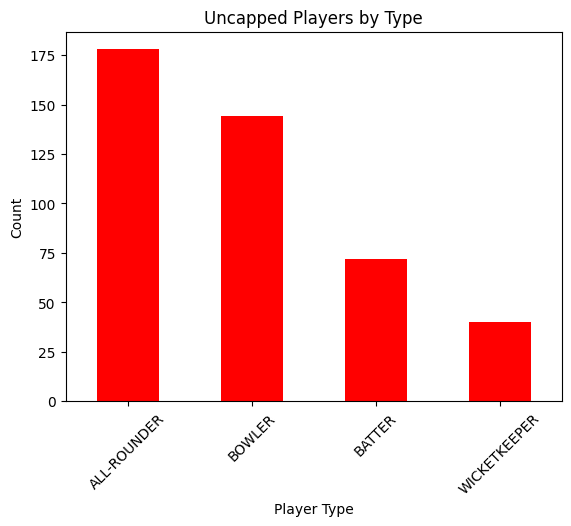

In [15]:
df[df['2021 Squad'].isna()]['TYPE'].value_counts().plot(kind='bar', color='red')
plt.title('Uncapped Players by Type')
plt.xlabel('Player Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [16]:
print("=== IPL 2022 Auction Analysis - Key Findings ===")
print(f"Total Players Auctioned: {df.shape[0]}")
print(f"Most Expensive Player: {df.loc[df['COST IN ₹ (CR.)'].idxmax(), 'Player']} at {df['COST IN ₹ (CR.)'].max()} CR")
print(f"Most Expensive Player Type: {df.groupby('TYPE')['COST IN ₹ (CR.)'].mean().idxmax()}")
print(f"Biggest Spending Team: {df.groupby('Team')['COST IN ₹ (CR.)'].sum().idxmax()}")
print(f"Team with Most Players: {df.groupby('Team')['Player'].count().idxmax()}")

=== IPL 2022 Auction Analysis - Key Findings ===
Total Players Auctioned: 633
Most Expensive Player: KL Rahul at 17.0 CR
Most Expensive Player Type: WICKETKEEPER
Biggest Spending Team: Mumbai Indians
Team with Most Players: Unsold


In [17]:
print("=== IPL 2022 Auction Analysis - Key Findings ===")
print(f"Total Players Auctioned: {df.shape[0]}")
print(f"Most Expensive Player: {df.loc[df['COST IN ₹ (CR.)'].idxmax(), 'Player']} at {df['COST IN ₹ (CR.)'].max()} CR")
print(f"Most Expensive Player Type: {df.groupby('TYPE')['COST IN ₹ (CR.)'].mean().idxmax()}")
print(f"Biggest Spending Team: {df.groupby('Team')['COST IN ₹ (CR.)'].sum().idxmax()}")

sold = df[df['Team'] != 'Unsold']
print(f"Team with Most Players Bought: {sold.groupby('Team')['Player'].count().idxmax()}")
print(f"Total Unsold Players: {df[df['Team'] == 'Unsold'].shape[0]}")

=== IPL 2022 Auction Analysis - Key Findings ===
Total Players Auctioned: 633
Most Expensive Player: KL Rahul at 17.0 CR
Most Expensive Player Type: WICKETKEEPER
Biggest Spending Team: Mumbai Indians
Team with Most Players Bought: Chennai Super Kings
Total Unsold Players: 396
